In [31]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('../data/processed/fitbit_feature_engineered.csv')

In [3]:
df.columns

Index(['Age', 'Gender', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration_hours', 'Workout_Type',
       'Fat_Percentage', 'Water_Intake_liters',
       'Workout_Frequency_days_per_week', 'Experience_Level', 'BMI',
       'Base_MET', 'HR_Intensity', 'Effective_MET', 'Calories_Burned_kcal',
       'Fat_Category', 'BMI_Category', 'Weekly_Workout_Hours'],
      dtype='object')

In [7]:
df.shape

(14102, 21)

In [6]:
corr_target = df.select_dtypes("number").corr()["Calories_Burned_kcal"].sort_values(ascending=False)
corr_target


Calories_Burned_kcal               1.000000
Effective_MET                      0.704388
Base_MET                           0.692492
HR_Intensity                       0.687703
Session_Duration_hours             0.573267
Weekly_Workout_Hours               0.499311
Avg_BPM                            0.487559
Experience_Level                   0.415616
Workout_Frequency_days_per_week    0.360209
Weight_kg                          0.305190
BMI                                0.248091
Water_Intake_liters                0.211870
Height_m                           0.177545
Age                                0.004587
Max_BPM                           -0.004969
Fat_Percentage                    -0.293446
Resting_BPM                       -0.295764
Name: Calories_Burned_kcal, dtype: float64

In [32]:
# Check current dataset shape
print("Original dataset shape:", df.shape)

# Columns suspected of leakage
leakage_cols = [
    'Base_MET',
    'Effective_MET',
    'HR_Intensity'
]

# Remove leakage columns
df = df.drop(columns=leakage_cols, errors='ignore')

# Check updated shape
print("Updated dataset shape:", df.shape)

# Display remaining columns
print("\nRemaining columns:")
print(df.columns.tolist())

Original dataset shape: (14102, 21)
Updated dataset shape: (14102, 18)

Remaining columns:
['Age', 'Gender', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration_hours', 'Workout_Type', 'Fat_Percentage', 'Water_Intake_liters', 'Workout_Frequency_days_per_week', 'Experience_Level', 'BMI', 'Calories_Burned_kcal', 'Fat_Category', 'BMI_Category', 'Weekly_Workout_Hours']


In [ ]:
# Target column
target = 'Calories_Burned_kcal'

X = df.drop(columns=[target])
y = df[target]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (14102, 17)
Target shape: (14102,)


In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (11281, 17)
Testing data: (2821, 17)


In [36]:
# Numerical columns
numeric_features = X.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Categorical columns
categorical_features = X.select_dtypes(
    include=['object', 'category']
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Age', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration_hours', 'Fat_Percentage', 'Water_Intake_liters', 'Workout_Frequency_days_per_week', 'Experience_Level', 'BMI', 'Weekly_Workout_Hours']

Categorical features:
['Gender', 'Workout_Type', 'Fat_Category', 'BMI_Category']


In [37]:

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('numeric', numeric_pipeline, numeric_features),
        ('categorical', categorical_pipeline, categorical_features)
    ]
)

In [38]:
models = {
    'Linear Regression': LinearRegression(),

    'KNN Regression': KNeighborsRegressor(
        n_neighbors=5
    ),

    'Decision Tree': DecisionTreeRegressor(
        random_state=42
    ),

    'Random Forest': RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    'SVR': SVR(),

    'XGBoost': XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective='reg:squarederror'
    )
}

In [39]:
results = []

for model_name, model in models.items():

    # Create complete pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    # Train model
    model_pipeline.fit(X_train, y_train)

    # Make predictions
    y_pred = model_pipeline.predict(X_test)

    # Evaluation metrics
    mae = mean_absolute_error(y_test, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_test, y_pred)
    )

    r2 = r2_score(y_test, y_pred)

    # Store results
    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Convert results into DataFrame
results_df = pd.DataFrame(results)

# Sort by R2 score
results_df = results_df.sort_values(
    by='R2 Score',
    ascending=False
)

# Display results
print(results_df)

               Model        MAE       RMSE  R2 Score
5            XGBoost   3.774340   5.845372  0.998912
3      Random Forest   3.880257   8.678664  0.997601
2      Decision Tree   8.509500  14.816034  0.993008
1     KNN Regression  33.388224  48.889127  0.923871
0  Linear Regression  34.631662  52.812043  0.911164
4                SVR  46.943049  81.247681  0.789746


In [40]:
best_model = results_df.iloc[0]

print("Best model based on R2 Score:")
print(best_model)

Best model based on R2 Score:
Model        XGBoost
MAE          3.77434
RMSE        5.845372
R2 Score    0.998912
Name: 5, dtype: object


In [41]:
print(df.columns.tolist())

['Age', 'Gender', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration_hours', 'Workout_Type', 'Fat_Percentage', 'Water_Intake_liters', 'Workout_Frequency_days_per_week', 'Experience_Level', 'BMI', 'Calories_Burned_kcal', 'Fat_Category', 'BMI_Category', 'Weekly_Workout_Hours']


In [42]:
import matplotlib.pyplot as plt

# Select model for prediction
selected_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Create pipeline
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', selected_model)
])

# Train final model
final_pipeline.fit(X_train, y_train)

# Predictions
y_pred = final_pipeline.predict(X_test)

# Compare actual and predicted values
comparison_df = pd.DataFrame({
    'Actual Calories': y_test.values,
    'Predicted Calories': y_pred
})

print(comparison_df.head(10))

   Actual Calories  Predicted Calories
0            352.9             354.006
1            504.1             506.079
2             93.2              93.235
3            127.7             122.145
4            275.8             227.452
5            464.0             461.252
6            256.2             256.194
7            497.8             493.810
8             73.8              71.050
9            464.6             482.054


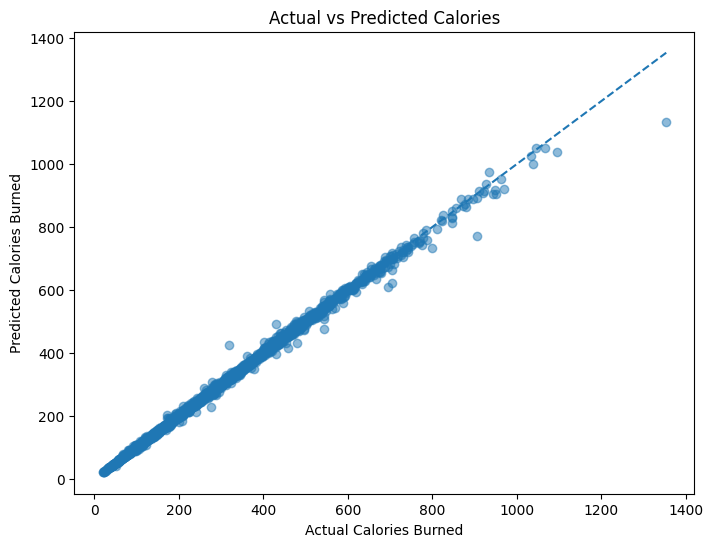

In [43]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.5)

plt.xlabel('Actual Calories Burned')
plt.ylabel('Predicted Calories Burned')
plt.title('Actual vs Predicted Calories')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle='--'
)

plt.show()

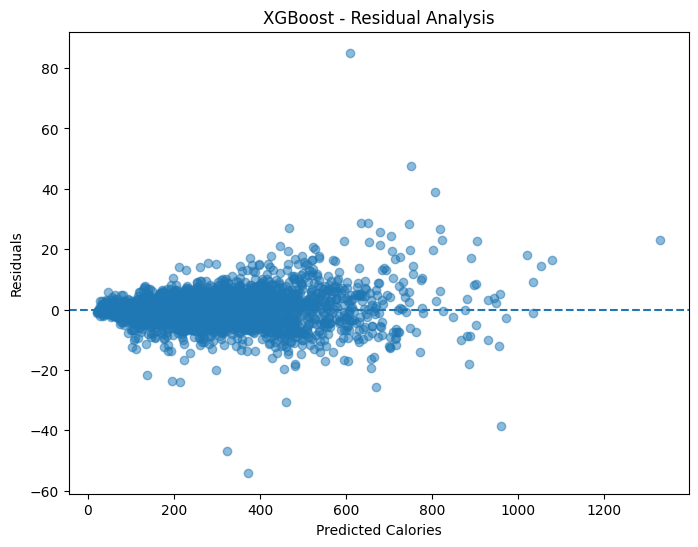

In [48]:
# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.5)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("XGBoost - Residual Analysis")

plt.show()

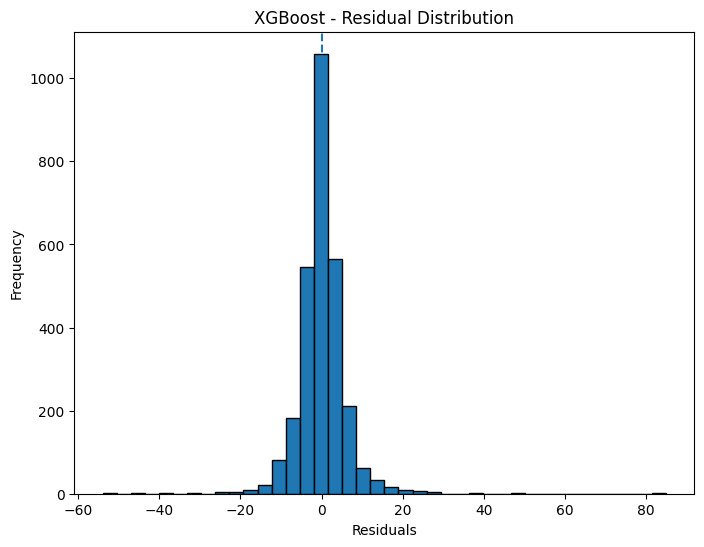

In [49]:
plt.figure(figsize=(8, 6))

plt.hist(residuals, bins=40, edgecolor="black")

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("XGBoost - Residual Distribution")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.show()

In [50]:
# Get feature names after preprocessing
feature_names = final_pipeline[
    'preprocessor'
].get_feature_names_out()

# Get XGBoost feature importance
importance_values = final_pipeline[
    'model'
].feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
})

# Sort by importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Display top 15 features
print(importance_df.head(15))

                                     Feature  Importance
16            categorical__Workout_Type_HIIT    0.417037
19            categorical__Workout_Type_Yoga    0.389279
17           categorical__Workout_Type_Mixed    0.082096
6            numeric__Session_Duration_hours    0.071124
1                         numeric__Weight_kg    0.022394
15          categorical__Workout_Type_Cardio    0.010379
18        categorical__Workout_Type_Strength    0.006919
12             numeric__Weekly_Workout_Hours    0.000262
13                categorical__Gender_Female    0.000089
3                           numeric__Max_BPM    0.000048
11                              numeric__BMI    0.000047
7                    numeric__Fat_Percentage    0.000044
9   numeric__Workout_Frequency_days_per_week    0.000039
4                           numeric__Avg_BPM    0.000037
10                 numeric__Experience_Level    0.000029


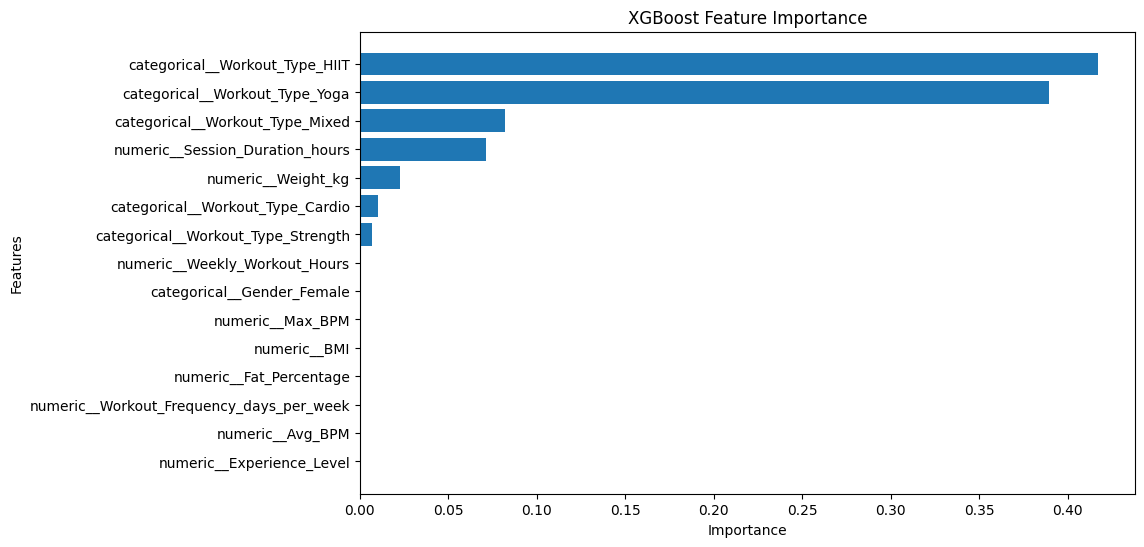

In [51]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Features')
plt.title('XGBoost Feature Importance')

plt.gca().invert_yaxis()

plt.show()

In [52]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_result = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    n_repeats=5,
    random_state=42,
    scoring='r2'
)

# Create importance DataFrame
perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_result.importances_mean
})

# Sort features
perm_df = perm_df.sort_values(
    by='Importance',
    ascending=False
)

# Display results
print(perm_df)

                            Feature    Importance
8                      Workout_Type  1.082728e+00
7            Session_Duration_hours  7.628732e-01
2                         Weight_kg  2.564072e-01
9                    Fat_Percentage  3.961296e-05
16             Weekly_Workout_Hours  3.660974e-05
3                          Height_m  2.354413e-05
13                              BMI  1.483620e-05
11  Workout_Frequency_days_per_week  8.112593e-06
6                       Resting_BPM  7.060410e-06
5                           Avg_BPM  5.603481e-06
12                 Experience_Level  2.511466e-06
1                            Gender  9.326634e-07
15                     BMI_Category  9.180398e-08
14                     Fat_Category -4.437635e-08
0                               Age -9.668332e-07
10              Water_Intake_liters -2.327208e-06
4                           Max_BPM -7.490464e-06


In [53]:
from sklearn.model_selection import GridSearchCV

In [54]:
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        random_state=42,
        objective='reg:squarederror'
    ))
])

In [55]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [3, 6],
    'model__learning_rate': [0.05, 0.1],
    'model__subsample': [0.8, 1.0]
}

In [56]:
grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 16 candidates, totalling 48 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 6], 'model__n_estimators': [100, 200], 'model__subsample': [0.8, 1.0]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('numeric', ...), ('categorical', ...)]"


In [57]:
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation R2:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best Cross-Validation R2:
0.9985


In [58]:
# Get the best tuned model
best_xgb_model = grid_search.best_estimator_

# Predict on test data
y_pred_tuned = best_xgb_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_tuned)

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_tuned)
)

r2 = r2_score(y_test, y_pred_tuned)

print("Tuned XGBoost Performance")
print("-------------------------")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R2 Score:", round(r2, 4))

Tuned XGBoost Performance
-------------------------
MAE: 3.19
RMSE: 5.09
R2 Score: 0.9992


In [59]:
print("Before Tuning R2:", round(r2_score(y_test, y_pred), 4))
print("After Tuning R2:", round(r2_score(y_test, y_pred_tuned), 4))

Before Tuning R2: 0.9989
After Tuning R2: 0.9992


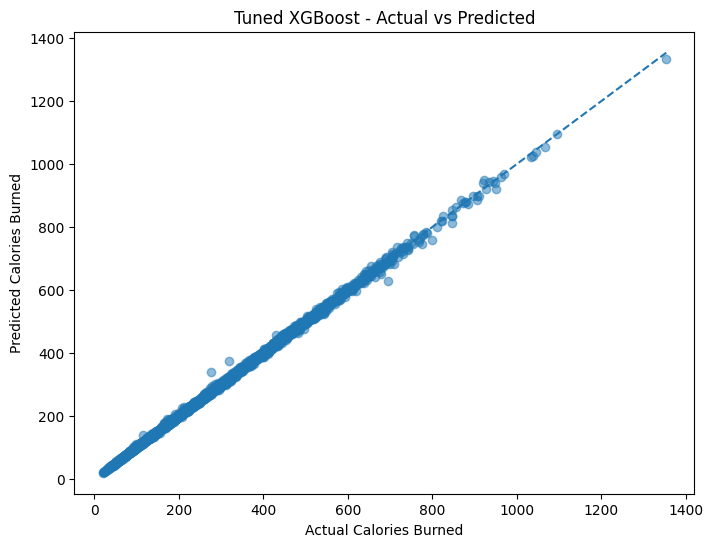

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_tuned, alpha=0.5)

plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Tuned XGBoost - Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

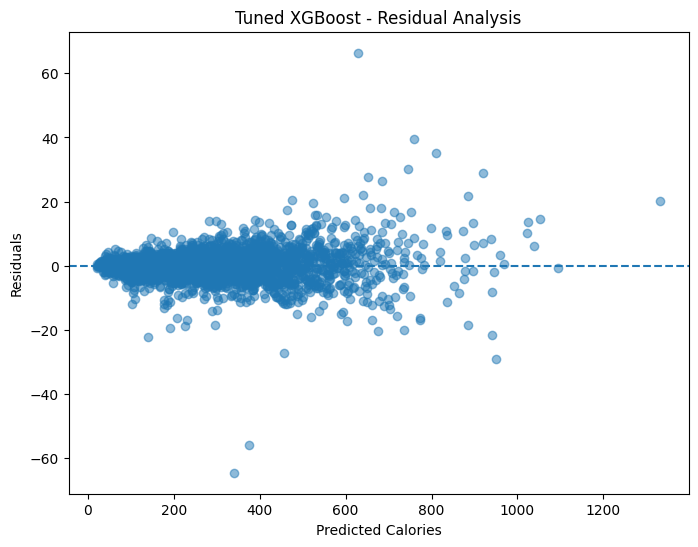

In [61]:
# Calculate tuned model residuals
tuned_residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_tuned,
    tuned_residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Tuned XGBoost - Residual Analysis")

plt.show()

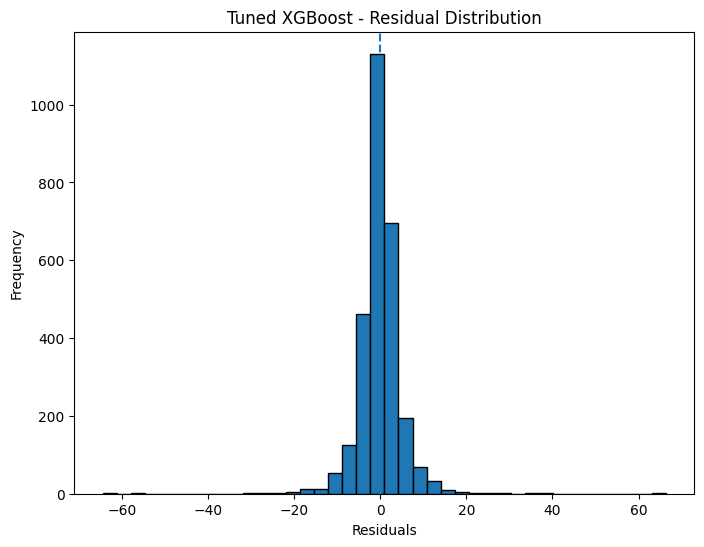

In [62]:
plt.figure(figsize=(8, 6))

plt.hist(
    tuned_residuals,
    bins=40,
    edgecolor="black"
)

plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Tuned XGBoost - Residual Distribution")

plt.axvline(
    x=0,
    linestyle="--"
)

plt.show()

In [63]:
# Compare original and tuned XGBoost

comparison = pd.DataFrame({
    'Model': [
        'Original XGBoost',
        'Tuned XGBoost'
    ],
    'MAE': [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, y_pred_tuned)
    ],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, y_pred_tuned))
    ],
    'R2 Score': [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_tuned)
    ]
})

print(comparison.round(4))

              Model     MAE    RMSE  R2 Score
0  Original XGBoost  3.7743  5.8454    0.9989
1     Tuned XGBoost  3.1879  5.0888    0.9992


In [64]:
print("Best XGBoost Parameters:")
print(grid_search.best_params_)

Best XGBoost Parameters:
{'model__learning_rate': 0.05, 'model__max_depth': 6, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [65]:
import joblib

# Save tuned XGBoost pipeline
joblib.dump(
    best_xgb_model,
    'tuned_xgboost_calorie_model.pkl'
)

print("Model saved successfully!")

Model saved successfully!


In [66]:
# Load saved model
loaded_model = joblib.load(
    'tuned_xgboost_calorie_model.pkl'
)

# Test loaded model
loaded_predictions = loaded_model.predict(X_test)

print("Loaded model R2 Score:",
      round(r2_score(y_test, loaded_predictions), 4))

Loaded model R2 Score: 0.9992


Workout Pattern Analysis Using Clustering

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

cluster_features = [
    "Age",
    "Weight_kg",
    "Height_m",
    "Max_BPM",
    "Avg_BPM",
    "Resting_BPM",
    "Session_Duration_hours",
    "Fat_Percentage",
    "Water_Intake_liters",
    "Workout_Frequency_days_per_week",
    "BMI",
    "Weekly_Workout_Hours"
]

X_cluster = df[cluster_features].copy()

print(X_cluster.head())

   Age  Weight_kg  Height_m  Max_BPM  Avg_BPM  Resting_BPM  \
0   56       53.8      1.62      163      149           71   
1   46       54.9      1.75      170      126           73   
2   32       68.5      1.61      190      171           60   
3   25       98.8      1.86      189      135           69   
4   38       95.5      1.71      176      138           66   

   Session_Duration_hours  Fat_Percentage  Water_Intake_liters  \
0                    1.01            22.1                  3.5   
1                    0.25            19.9                  3.4   
2                    0.33            20.4                  2.7   
3                    0.78            30.3                  4.4   
4                    0.55            23.7                  2.2   

   Workout_Frequency_days_per_week   BMI  Weekly_Workout_Hours  
0                                3  20.4                  3.03  
1                                3  18.0                  0.75  
2                                3 

In [68]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_cluster)

print(X_scaled.shape)

(14102, 12)


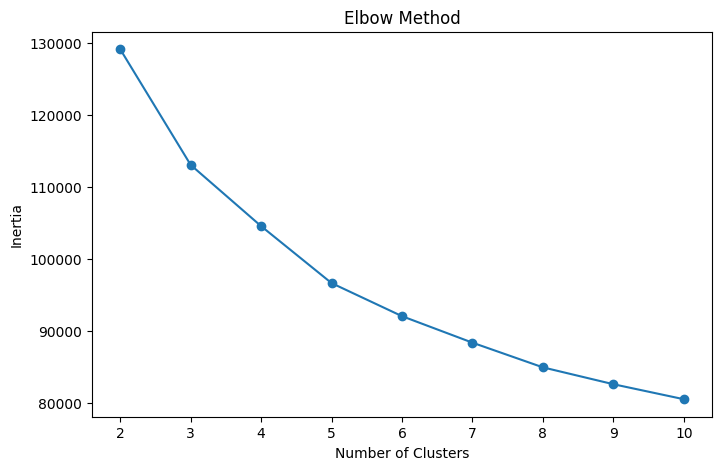

In [69]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [70]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Workout_Cluster"] = kmeans.fit_predict(X_scaled)

print(df["Workout_Cluster"].value_counts())

Workout_Cluster
2    4757
0    4715
1    4630
Name: count, dtype: int64


In [72]:
print(df.columns.tolist())

['Age', 'Gender', 'Weight_kg', 'Height_m', 'Max_BPM', 'Avg_BPM', 'Resting_BPM', 'Session_Duration_hours', 'Workout_Type', 'Fat_Percentage', 'Water_Intake_liters', 'Workout_Frequency_days_per_week', 'Experience_Level', 'BMI', 'Calories_Burned_kcal', 'Fat_Category', 'BMI_Category', 'Weekly_Workout_Hours', 'Workout_Cluster']


In [73]:
cluster_summary = df.groupby("Workout_Cluster")[
    cluster_features + ["Calories_Burned_kcal"]
].mean()

print(cluster_summary.round(2))

                   Age  Weight_kg  Height_m  Max_BPM  Avg_BPM  Resting_BPM  \
Workout_Cluster                                                              
0                48.84      68.26      1.68   170.41   139.84        72.28   
1                38.52      67.91      1.68   181.35   145.80        62.94   
2                28.31      68.58      1.68   192.34   158.10        72.64   

                 Session_Duration_hours  Fat_Percentage  Water_Intake_liters  \
Workout_Cluster                                                                
0                                  0.69           24.49                 3.42   
1                                  1.12           16.59                 3.99   
2                                  0.69           24.33                 3.40   

                 Workout_Frequency_days_per_week    BMI  Weekly_Workout_Hours  \
Workout_Cluster                                                                 
0                                           3.

In [74]:
workout_pattern = pd.crosstab(
    df["Workout_Cluster"],
    df["Workout_Type"]
)

print(workout_pattern)

Workout_Type     Cardio  HIIT  Mixed  Strength  Yoga
Workout_Cluster                                     
0                  1037   808    854       946  1070
1                   824   884   1068       886   968
2                   913  1206    900      1006   732


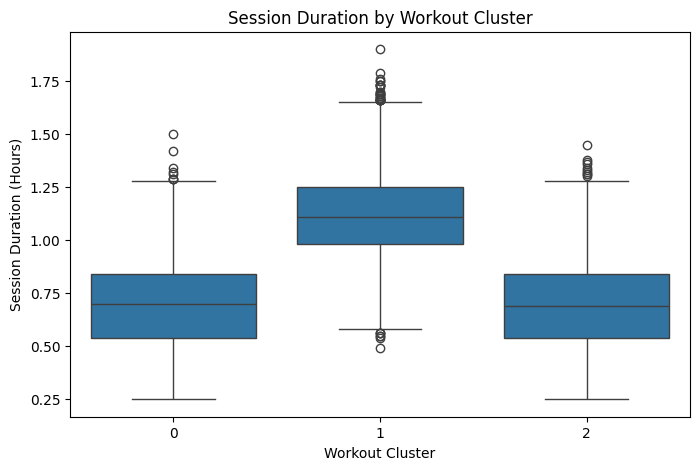

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Workout_Cluster",
    y="Session_Duration_hours"
)

plt.title("Session Duration by Workout Cluster")
plt.xlabel("Workout Cluster")
plt.ylabel("Session Duration (Hours)")
plt.show()

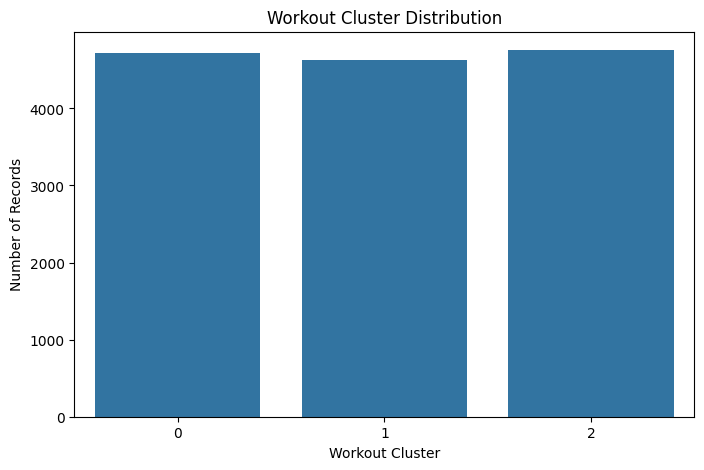

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Workout_Cluster"
)

plt.title("Workout Cluster Distribution")
plt.xlabel("Workout Cluster")
plt.ylabel("Number of Records")
plt.show()

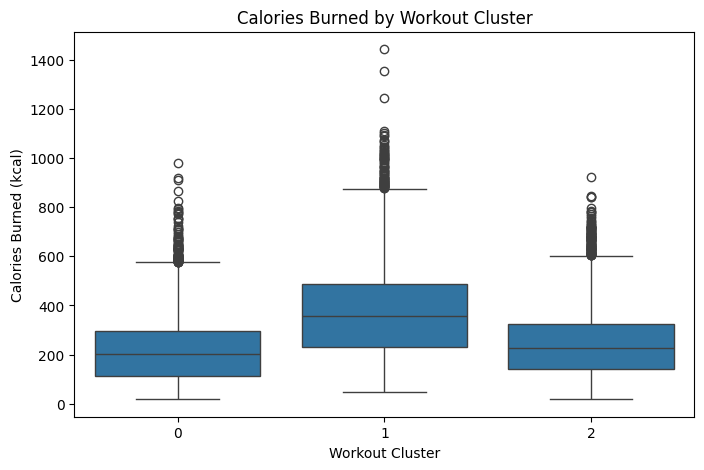

In [77]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Workout_Cluster",
    y="Calories_Burned_kcal"
)

plt.title("Calories Burned by Workout Cluster")
plt.xlabel("Workout Cluster")
plt.ylabel("Calories Burned (kcal)")
plt.show()

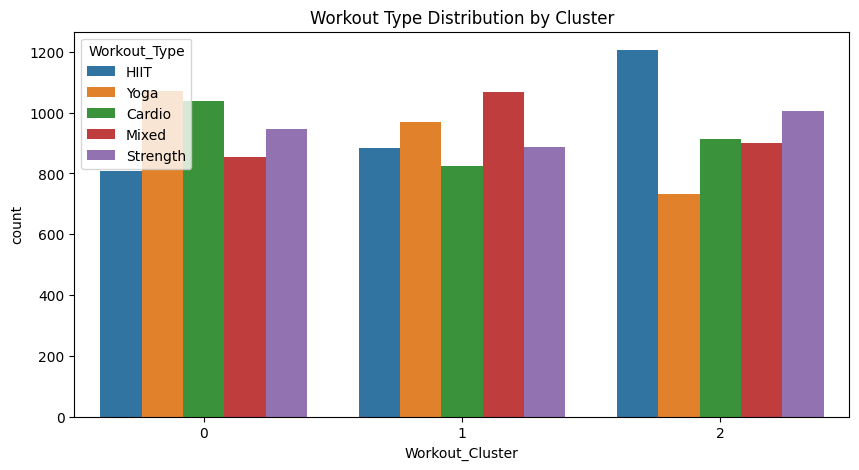

In [78]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Workout_Cluster",
    hue="Workout_Type"
)

plt.title("Workout Type Distribution by Cluster")
plt.show()

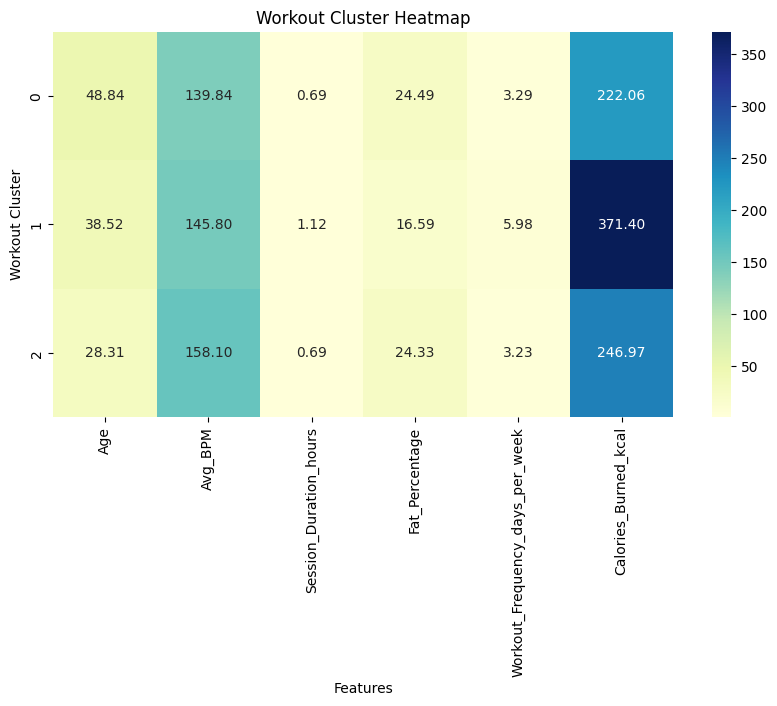

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select important features
heatmap_features = [
    "Age",
    "Avg_BPM",
    "Session_Duration_hours",
    "Fat_Percentage",
    "Workout_Frequency_days_per_week",
    "Calories_Burned_kcal"
]

heatmap_data = df.groupby("Workout_Cluster")[
    heatmap_features
].mean()

plt.figure(figsize=(10, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title("Workout Cluster Heatmap")
plt.xlabel("Features")
plt.ylabel("Workout Cluster")

plt.show()

In [80]:
cluster_percentage = (
    df["Workout_Cluster"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(cluster_percentage)

Workout_Cluster
2    33.73
0    33.43
1    32.83
Name: proportion, dtype: float64


In [81]:
dominant_workout = pd.crosstab(
    df["Workout_Cluster"],
    df["Workout_Type"],
    normalize="index"
).mul(100).round(2)

print(dominant_workout)

Workout_Type     Cardio   HIIT  Mixed  Strength   Yoga
Workout_Cluster                                       
0                 21.99  17.14  18.11     20.06  22.69
1                 17.80  19.09  23.07     19.14  20.91
2                 19.19  25.35  18.92     21.15  15.39


In [82]:
final_cluster_report = df.groupby("Workout_Cluster").agg(
    Average_Age=("Age", "mean"),
    Average_Duration=("Session_Duration_hours", "mean"),
    Average_BPM=("Avg_BPM", "mean"),
    Average_Frequency=("Workout_Frequency_days_per_week", "mean"),
    Average_Calories=("Calories_Burned_kcal", "mean"),
    Record_Count=("Workout_Cluster", "count")
).round(2)

print(final_cluster_report)

                 Average_Age  Average_Duration  Average_BPM  \
Workout_Cluster                                               
0                      48.84              0.69       139.84   
1                      38.52              1.12       145.80   
2                      28.31              0.69       158.10   

                 Average_Frequency  Average_Calories  Record_Count  
Workout_Cluster                                                     
0                             3.29            222.06          4715  
1                             5.98            371.40          4630  
2                             3.23            246.97          4757  


In [83]:
import joblib

# Save scaler
joblib.dump(scaler, "cluster_scaler.pkl")

# Save K-Means model
joblib.dump(kmeans, "workout_kmeans_model.pkl")

# Save clustered dataset
df.to_csv("workout_clustered_data.csv", index=False)

print("Clustering model and dataset saved successfully!")

Clustering model and dataset saved successfully!


In [84]:
import os

files = [
    "cluster_scaler.pkl",
    "workout_kmeans_model.pkl",
    "workout_clustered_data.csv"
]

for file in files:
    print(file, "->", os.path.exists(file))

cluster_scaler.pkl -> True
workout_kmeans_model.pkl -> True
workout_clustered_data.csv -> True
